<a href="https://colab.research.google.com/github/Yubraj45/CreditCardFraudDetection/blob/main/Credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
df= pd.read_csv('creditcard.csv')

In [71]:
df.shape

(284807, 31)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [73]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [74]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [75]:
df = df.dropna(subset=['Class']).reset_index(drop=True)

In [76]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(random_state=42)
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), ['Time', 'Amount'])
], remainder='passthrough')

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)),
    ('classifier', RandomForestClassifier( class_weight='balanced',n_estimators=200,          # Reduce from 500/1000 if you had high
        max_depth=10,              # Very important - limit depth
        min_samples_leaf=2,
        max_features='sqrt',       # Important for speed
        n_jobs=-1,                 # Use all CPU cores
          # Good for your imbalance
        random_state=42,
        bootstrap=True))
])

In [78]:
X= df.drop('Class', axis=1)
y= df['Class']

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=0)


In [80]:
model_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Time', 'Amount'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=2, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [81]:
y_pred= model_pipeline.predict(X_test)
y_prob_pred= model_pipeline.predict_proba(X_test)[:,1]

In [82]:
#PROPER TIME-BASED SPLIT
df_sorted = df.sort_values(by='Time')
X_sorted = df_sorted.drop('Class', axis=1)
y_sorted = df_sorted['Class']

#CHRONOLOGICAL SPLIT( NO SUFFLING)
split_idx = int(0.8 * len(X_sorted))
X_train_time = X_sorted.iloc[:split_idx]
X_test_time = X_sorted.iloc[split_idx:]
y_train_time = y_sorted.iloc[:split_idx]
y_test_time = y_sorted.iloc[split_idx:]

#TRANING AND EVALUATING
rf.fit(X_train_time, y_train_time)
y_probs_time = rf.predict_proba(X_test_time)[:, 1]
y_pred_time = (y_probs_time > 0.55).astype(int)




#COMPARISON
from sklearn.metrics import recall_score, precision_score

print("COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Metric':<15} {'Random Split':<15} {'Time Split':<15} {'Difference':<15}")
print("-" * 60)
print(f"{'Recall':<15} {recall_score(y_test, y_pred):<15.3f} {recall_score(y_test_time, y_pred_time):<15.3f} {(recall_score(y_test, y_pred) - recall_score(y_test_time, y_pred_time)):<15.3f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred):<15.3f} {precision_score(y_test_time, y_pred_time):<15.3f} {(precision_score(y_test, y_pred) - precision_score(y_test_time, y_pred_time)):<15.3f}")

if recall_score(y_test, y_pred) - recall_score(y_test_time, y_pred_time) > 0.10:
    print("\n⚠️ WARNING: Your model overestimates performance by >10%!")
    print("   The random split results are NOT trustworthy for production.")

COMPARISON SUMMARY
Metric          Random Split    Time Split      Difference     
------------------------------------------------------------
Recall          0.842           0.667           0.175          
Precision       0.833           0.980           -0.147         

⚠️ WARNING: Your model overestimates performance by >10%!
   The random split results are NOT trustworthy for production.


In [83]:
import seaborn as sns
from sklearn.metrics import classification_report , confusion_matrix , roc_auc_score , average_precision_score

In [84]:
# print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
# print("PR-AUC Score (Average Precision):", average_precision_score(y_test, y_pred_proba))
# threshold = 0.5
# y_pred = (y_prob_pred >= threshold).astype(int)

In [85]:
# thresholds = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.98, 0.99]
# results=[]

# for threshold in thresholds:
#   y_pred= (y_prob_pred >= threshold).astype(int)

#   report = classification_report(y_test, y_pred, output_dict=True)
#   fraud_metrics = report.get('1', {'precision': 0, 'recall': 0, 'f1-score': 0})
#   results.append({
#         'Threshold': threshold,
#         'Precision (Fraud)': round(fraud_metrics['precision'], 4),
#         'Recall (Fraud)': round(fraud_metrics['recall'], 4),
#         'F1 (Fraud)': round(fraud_metrics['f1-score'], 4),
#         'Fraud_Predicted': y_pred.sum()
#     })

# df_results = pd.DataFrame(results)
# print(df_results)

In [86]:
from sklearn.metrics import f1_score
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
time_results = []
for thresh in thresholds:
    y_pred = (y_probs_time > thresh).astype(int)
    time_results.append({
        'threshold': thresh,
        'recall': recall_score(y_test_time, y_pred),
        'precision': precision_score(y_test_time, y_pred),
        'f1': f1_score(y_test_time, y_pred),
        'fraud_caught': y_pred.sum()
    })
    results_df = pd.DataFrame(time_results)
print("Threshold Analysis on REALISTIC (Time Split) Data:")
print(results_df)

best_recall_thresh = results_df[results_df['recall'] > 0.75]['threshold'].min()
print(f"\nThreshold to achieve 75% recall: {best_recall_thresh}")

# For best F1 score:
best_f1 = results_df.loc[results_df['f1'].idxmax(), 'threshold']
print(f"Threshold for best F1 score: {best_f1}")

Threshold Analysis on REALISTIC (Time Split) Data:
   threshold    recall  precision        f1  fraud_caught
0       0.30  0.733333   0.887097  0.802920            62
1       0.35  0.733333   0.932203  0.820896            59
2       0.40  0.720000   0.947368  0.818182            57
3       0.45  0.706667   0.963636  0.815385            55
4       0.50  0.693333   0.981132  0.812500            53
5       0.55  0.666667   0.980392  0.793651            51
6       0.60  0.653333   1.000000  0.790323            49

Threshold to achieve 75% recall: nan
Threshold for best F1 score: 0.35


In [87]:
optimal_threshold=0.35
y_pred= (y_prob_pred >= optimal_threshold).astype(int)


In [88]:
print(model_pipeline.named_steps['classifier'])

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                       random_state=42)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56861
           1       0.74      0.85      0.79       101

    accuracy                           1.00     56962
   macro avg       0.87      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



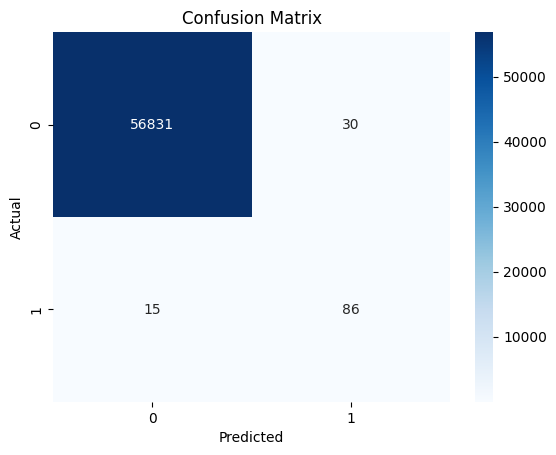

ROC_AUC Score: 0.9895271794462822
PR_AUC Score (Average Precision): 0.8128811861041983


In [89]:
print(classification_report(y_test ,y_pred))

cm= confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


print("ROC_AUC Score:", roc_auc_score(y_test, y_prob_pred))
print("PR_AUC Score (Average Precision):", average_precision_score(y_test, y_prob_pred))

In [90]:
def production_monitoring(y_true, y_pred, threshold=0.35):
    """Track these metrics weekly"""
    return {
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'alert_rate': y_pred.mean() * 100,  # % of transactions flagged
        'daily_alerts': len(y_pred) * y_pred.mean() / 30  # per day
    }